# Proyek Akhir: Menyelesaikan Permasalahan HR - Attrition Rate Tinggi

- Nama: Annisa Nur Fauzi
- Email: annisafauzii13@gmail.com
- Id Dicoding:

### Persiapan

Menyiapkan library yang dibutuhkan

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

Menyiapkan data yang dibutuhkan

In [ ]:
url = "https://raw.githubusercontent.com/cafauzi13/dicoding-data-science-terapan/refs/heads/main/proyek1_dashboard/employee_data.csv"

In [ ]:
df = pd.read_csv(url)
df.head()


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


### Data Understanding

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
# Cek distribusi target (Attrition)
print("\nJumlah Karyawan Keluar (Yes) vs Bertahan (No):")
print(df['Attrition'].value_counts())


Jumlah Karyawan Keluar (Yes) vs Bertahan (No):
Attrition
0.0    879
1.0    179
Name: count, dtype: int64


### Data Preparation

In [ ]:
# 1. Menghapus baris yang Attrition-nya kosong (NaN)
# Kita nggak bisa analisa/prediksi kalau labelnya aja nggak ada
df_clean = df.dropna(subset=['Attrition']).copy()

# 2. Menghapus kolom yang isinya cuma 1 nilai saja (tidak berguna)
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeId']
df_clean = df_clean.drop(columns=cols_to_drop)

# 3. Mengubah tipe data Attrition jadi integer (biar rapi jadi 0 dan 1)
df_clean['Attrition'] = df_clean['Attrition'].astype(int)

# Cek hasil pembersihan
print(f"Ukuran data setelah dibersihkan: {df_clean.shape}")
df_clean.head()

Ukuran data setelah dibersihkan: (1058, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,37,1,Travel_Rarely,1141,Research & Development,11,2,Medical,1,Female,...,3,1,0,15,2,1,1,0,0,0
2,51,1,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,Male,...,3,3,3,18,2,4,10,0,2,7
3,42,0,Travel_Frequently,555,Sales,26,3,Marketing,3,Female,...,3,4,1,23,2,4,20,4,4,8
6,40,0,Travel_Rarely,1124,Sales,1,2,Medical,2,Male,...,4,3,3,6,2,2,4,3,0,2
7,55,1,Travel_Rarely,725,Research & Development,2,3,Medical,4,Male,...,3,4,1,24,2,3,5,2,1,4


In [ ]:
# Cek apakah ada baris yang sama persis
print(f"Jumlah data duplikat: {df_clean.duplicated().sum()}")

# Kalau ada (meskipun biasanya data ini bersih), kita hapus:
df_clean = df_clean.drop_duplicates()

Jumlah data duplikat: 0


In [ ]:
# Mengelompokkan Gaji (MonthlyIncome) menjadi 3 kategori
def kelompok_gaji(income):
    if income < 5000:
        return 'Low'
    elif 5000 <= income < 10000:
        return 'Medium'
    else:
        return 'High'

df_clean['IncomeGroup'] = df_clean['MonthlyIncome'].apply(kelompok_gaji)

# Mengelompokkan Umur
def kelompok_umur(age):
    if age < 30:
        return 'Young'
    elif 30 <= age < 45:
        return 'Middle-Aged'
    else:
        return 'Senior'

df_clean['AgeGroup'] = df_clean['Age'].apply(kelompok_umur)

Ubah kolom kategorikal jadi numerik


In [ ]:
# 1. Manual Mapping untuk kolom yang punya urutan/binary
df_clean['OverTime'] = df_clean['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)
df_clean['Gender'] = df_clean['Gender'].apply(lambda x: 1 if x == 'Male' else 0)

# Business Travel: Kita asumsikan urutannya (0: No Travel, 1: Rarely, 2: Frequently)
travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df_clean['BusinessTravel'] = df_clean['BusinessTravel'].map(travel_map)

# 2. One-Hot Encoding untuk sisa kolom kategorikal (Department, EducationField, JobRole, MaritalStatus)
# Ini akan membuat kolom baru untuk setiap kategori (misal: JobRole_Sales, JobRole_Manager, dst)
df_clean = pd.get_dummies(df_clean, columns=['Department', 'EducationField', 'JobRole', 'MaritalStatus'])

# 3. Pastikan semua kolom sekarang bertipe angka (True/False akan jadi 1/0 otomatis di ML)
# Simpan dataset yang sudah benar-benar numeric
df_clean.to_csv('employee_data_cleaned.csv', index=False)

print("Data Preparation Selesai! Semua kolom kategorikal sudah dikonversi ke numerik.")
print(f"Jumlah kolom sekarang: {df_clean.shape[1]}")
df_clean.head()

Data Preparation Selesai! Semua kolom kategorikal sudah dikonversi ke numerik.
Jumlah kolom sekarang: 51


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
1,37,1,1,1141,11,2,1,0,61,1,...,False,False,False,False,False,False,False,False,True,False
2,51,1,1,1323,4,4,1,1,34,3,...,False,False,False,False,True,False,False,False,True,False
3,42,0,2,555,26,3,3,0,77,3,...,False,False,False,False,False,True,False,False,True,False
6,40,0,1,1124,1,2,2,1,57,1,...,False,False,False,False,False,True,False,False,True,False
7,55,1,1,725,2,3,4,1,78,3,...,False,True,False,False,False,False,False,False,True,False


Analisis Korelasi

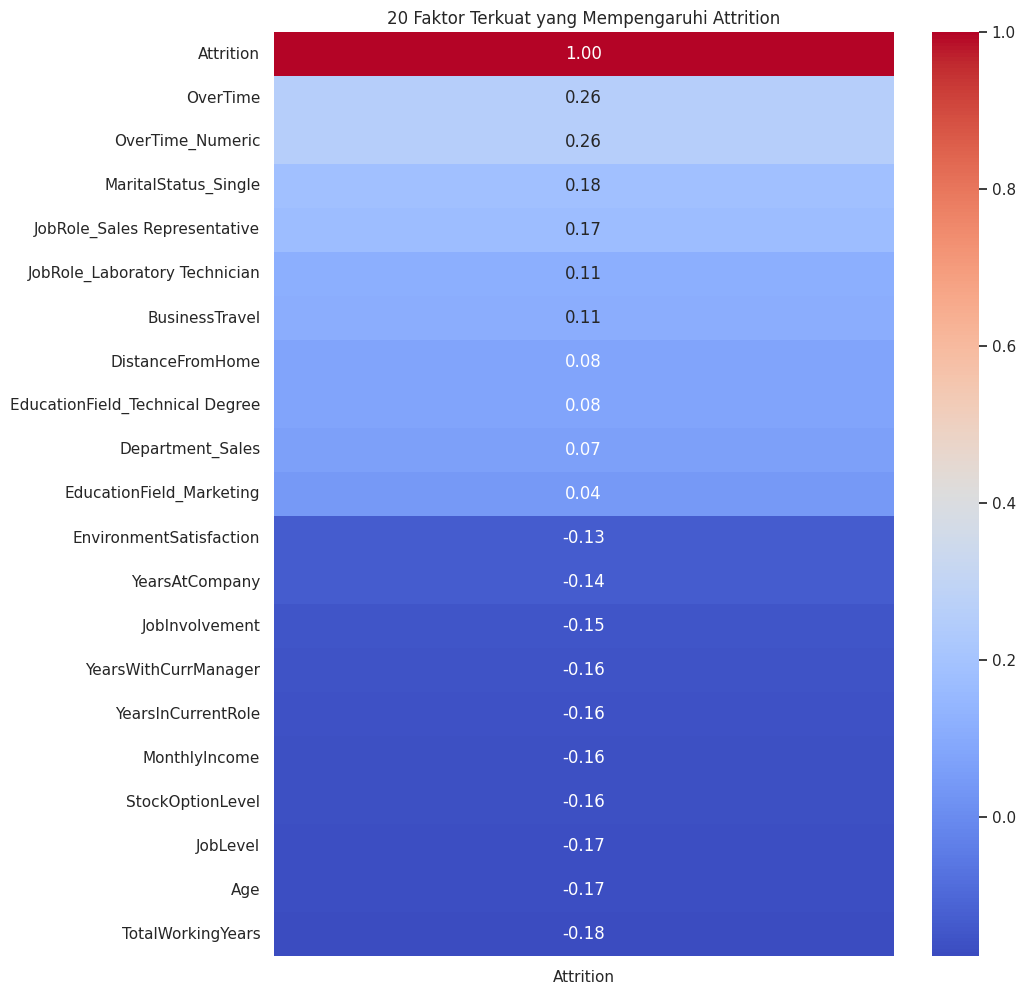

In [ ]:
# 1. Visualisasi Korelasi (Top 20 Faktor)
plt.figure(figsize=(10, 12))

# numeric_only=True
corr_attrition = df_clean.corr(numeric_only=True)[['Attrition']].sort_values(by='Attrition', ascending=False)

# Ambil 10 teratas (korelasi positif) dan 10 terbawah (korelasi negatif)
# Pastikan kita tidak mengambil lebih banyak dari jumlah kolom yang ada
top_bottom_corr = pd.concat([corr_attrition.head(11), corr_attrition.tail(10)])

sns.heatmap(top_bottom_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('20 Faktor Terkuat yang Mempengaruhi Attrition')
plt.show()

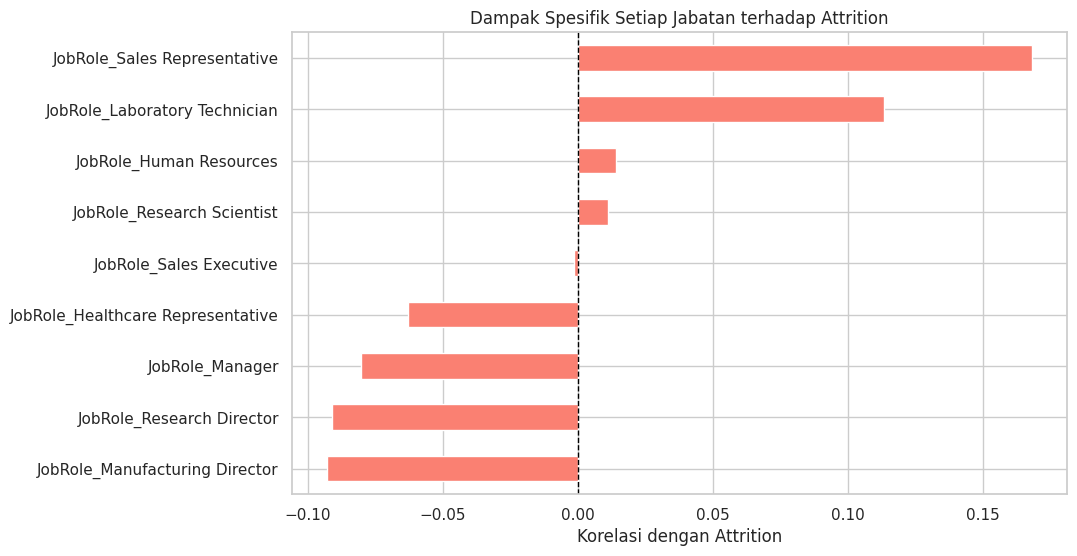

In [ ]:
# 2. Visualisasi Dampak Jabatan (Job Role)
job_role_corr = corr_attrition[corr_attrition.index.str.contains('JobRole')]

plt.figure(figsize=(10, 6))
job_role_corr['Attrition'].sort_values().plot(kind='barh', color='salmon')
plt.title('Dampak Spesifik Setiap Jabatan terhadap Attrition')
plt.xlabel('Korelasi dengan Attrition')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.show()

Berdasarkan hasil visualisasi data korelasi, berikut adalah kesimpulan mengenai faktor-faktor yang memengaruhi *attrition* (pengunduran diri karyawan) pada perusahaan Jaya Jaya Maju:

### 1. Pemicu Utama Attrition (Korelasi Positif)
* **Beban Kerja Ekstra:** Faktor **OverTime** (Lembur) merupakan prediktor terkuat dengan nilai korelasi **0.26**. Karyawan yang memiliki jam kerja lembur menunjukkan kecenderungan pengunduran diri yang lebih tinggi dibandingkan faktor lainnya.
* **Status Personal:** Karyawan dengan status **MaritalStatus_Single** memiliki korelasi positif sebesar **0.18**, menjadikannya faktor demografi paling dominan dalam tren *attrition*.
* **Mobilitas dan Logistik:** Intensitas perjalanan bisnis (**BusinessTravel**) dan jarak tempat tinggal ke kantor (**DistanceFromHome**) berkontribusi positif terhadap angka pengunduran diri karyawan.

### 2. Faktor Penahan Attrition (Korelasi Negatif)
* **Stabilitas Karier dan Senioritas:** Faktor **TotalWorkingYears (-0.18)**, **Age (-0.17)**, dan **JobLevel (-0.17)** menunjukkan hubungan berbanding terbalik yang konsisten. Semakin senior, semakin matang usia, dan semakin tinggi level jabatan seorang karyawan, maka kecenderungan untuk mengundurkan diri semakin rendah.
* **Kompensasi dan Keuntungan:** Tingkat pendapatan bulanan (**MonthlyIncome**) dan kepemilikan saham (**StockOptionLevel**) memiliki korelasi negatif sebesar **-0.16**, yang menunjukkan bahwa kesejahteraan finansial menjadi faktor penahan karyawan untuk tetap bertahan di perusahaan.
* **Keterlibatan Kerja:** Nilai korelasi pada **JobInvolvement (-0.15)** dan **YearsWithCurrManager (-0.16)** menunjukkan bahwa hubungan dengan atasan langsung dan keterlibatan emosional dalam pekerjaan berbanding terbalik dengan angka *attrition*.

### 3. Analisis Berdasarkan Jabatan (*Job Role*)
* **Jabatan Rentan (Vulnerable Roles):** **Sales Representative** merupakan posisi yang paling terdampak dengan korelasi positif tertinggi terhadap *attrition*, diikuti oleh **Laboratory Technician**. Keduanya menunjukkan tingkat kerawanan pengunduran diri yang paling signifikan dibandingkan peran lainnya.
* **Jabatan Stabil (Stable Roles):** Posisi manajemen dan kepemilikan teknis tinggi seperti **Manufacturing Director**, **Research Director**, dan **Manager** menunjukkan korelasi negatif yang kuat. Hal ini mengindikasikan tingkat retensi yang tinggi pada posisi-posisi kepemimpinan tersebut.


### Modelling

Feature selection

In [34]:
# Kita buang target (Attrition) dan kolom teks asli/redundant
X = df_clean.drop(columns=[
    'Attrition',
    'OverTime',    # Karena sudah ada OverTime_Numeric atau hasil encoding
    'IncomeGroup', # Karena ini versi teks (Low/High) yang kita buat tadi
    'AgeGroup'     # Karena ini versi teks (Young/Old) yang kita buat tadi
])

y = df_clean['Attrition']



Splitting & Training Data

In [37]:
# Kita pakai stratify=y supaya perbandingan 'Yes' dan 'No' di data latihan & tes tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# BLOCK: TRAINING
# Pakai 100 pohon (n_estimators) agar hasil stabil
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Simpan Model

In [39]:
import joblib

# Simpan model ke file
joblib.dump(model, 'model_hr_attrition.pkl')

# Simpan daftar kolom fitur (penting agar script prediksi tahu urutan kolomnya)
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

from google.colab import files
files.download('model_hr_attrition.pkl')
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Evaluation

--- Hasil Evaluasi Model ---
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       176
           1       0.83      0.14      0.24        36

    accuracy                           0.85       212
   macro avg       0.84      0.57      0.58       212
weighted avg       0.85      0.85      0.80       212



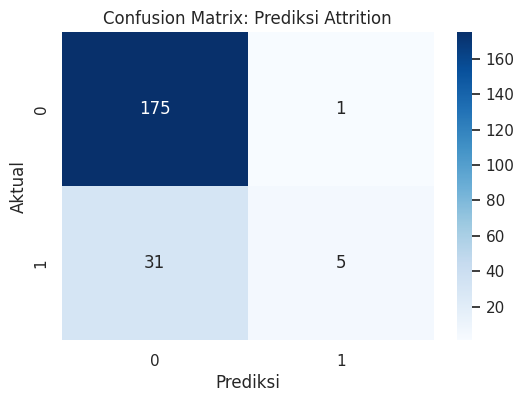

In [38]:
y_pred = model.predict(X_test)
print("--- Hasil Evaluasi Model ---")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix (Biar makin pro)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix: Prediksi Attrition')
plt.show()

Model memiliki akurasi yang cukup baik yaitu 85%. Namun, nilai Recall untuk kelas Attrition (1) masih rendah (0.14). Hal ini disebabkan oleh data yang tidak seimbang (imbalanced data). Model sangat baik dalam mengenali karyawan yang bertahan, namun masih kesulitan mendeteksi karyawan yang akan keluar